# Model V6 — Final Results

Walk-forward backtesting results.  
Run `python -m src.model_v6.train_n_evaluate` from the repo root first to generate output CSVs.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import r2_score

OUT_DIR = os.path.join('..', '..', 'poc_outputs_v6')

MODEL_ORDER  = ['spline', 'xgb', 'rf', 'ftt', 'pick_bin']
MODEL_LABELS = {
    'spline':   'Spline Ridge',
    'xgb':      'XGBoost',
    'rf':       'Random Forest',
    'ftt':      'FT-Transformer',
    'pick_bin': 'Pick Bin Mean',
}
MODEL_COLORS = {
    'spline':   '#3B6FB6',  # blue
    'xgb':      '#2A9D8F',  # teal
    'rf':       '#F4A261',  # orange
    'ftt':      '#9B59B6',  # purple
    'pick_bin': '#888888',  # grey
}


def nice_axes(ax):
    ax.grid(True, linestyle='--', linewidth=0.6, alpha=0.35)
    ax.set_axisbelow(True)
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)

In [2]:
results_df = pd.read_csv(os.path.join(OUT_DIR, 'model_v6_walkforward_results.csv'))
preds_2024 = pd.read_csv(os.path.join(OUT_DIR, 'model_v6_latest_year_predictions_2024.csv'))
print(f'Walk-forward folds : {len(results_df)}')
print(f'2024 picks         : {len(preds_2024)}')
print(f'Test years         : {results_df.test_year.min()} – {results_df.test_year.max()}')

Walk-forward folds : 18
2024 picks         : 257
Test years         : 2007 – 2024


## MAE over draft years

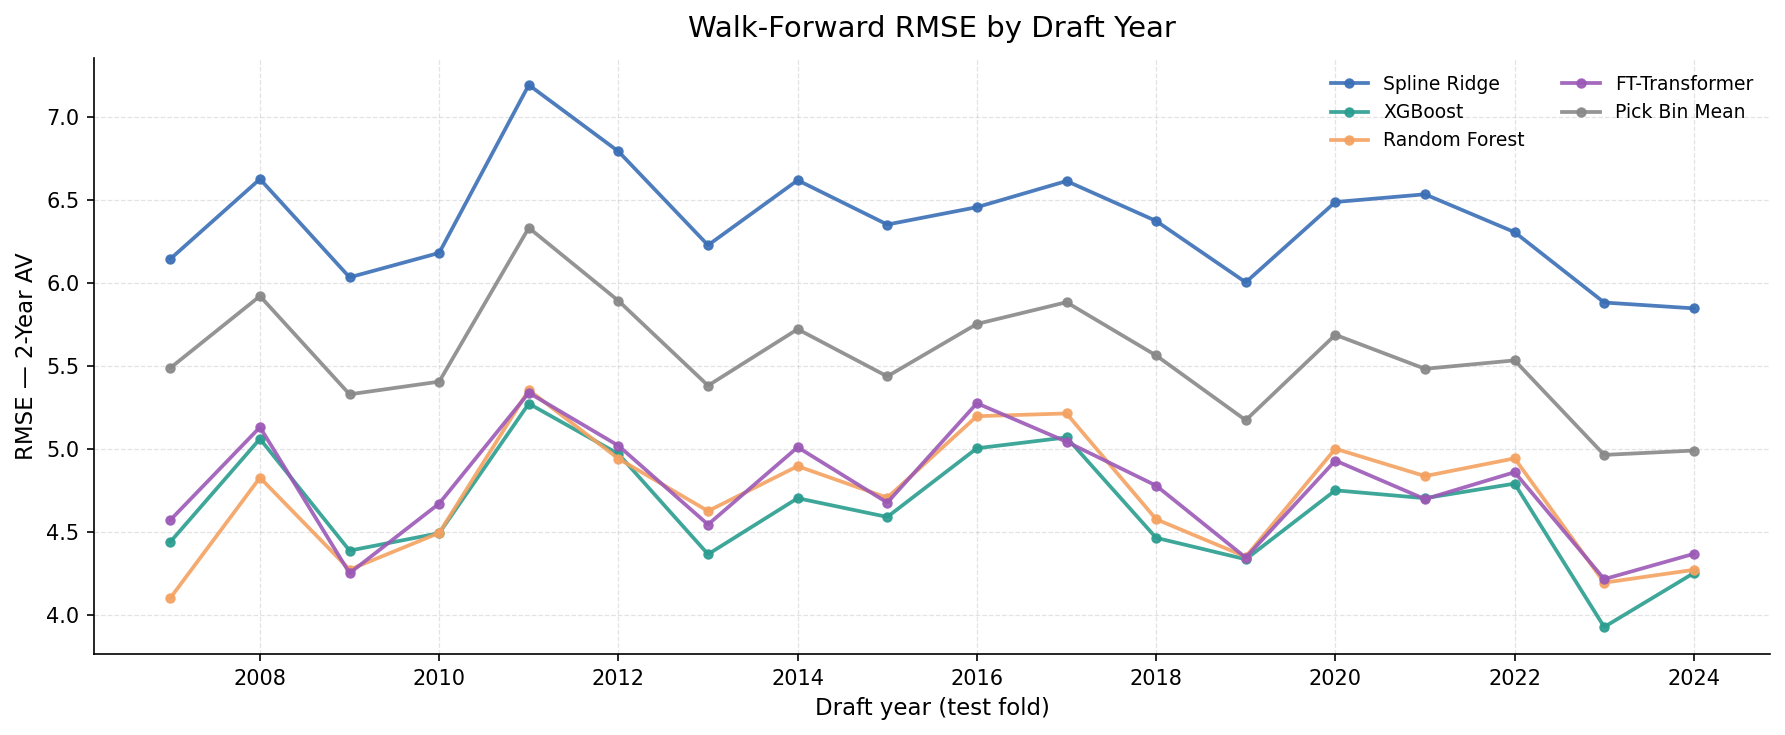

In [4]:
fig, ax = plt.subplots(figsize=(12, 5), dpi=150)

for model in MODEL_ORDER:
    col = f'{model}_rmse'
    if col not in results_df.columns:
        continue
    ax.plot(
        results_df['test_year'], results_df[col],
        marker='o', linewidth=1.8, markersize=4,
        color=MODEL_COLORS[model], label=MODEL_LABELS[model], alpha=0.9,
    )

ax.set_xlabel('Draft year (test fold)', fontsize=11)
ax.set_ylabel('RMSE — 2-Year AV', fontsize=11)
ax.set_title('Walk-Forward RMSE by Draft Year', fontsize=14, pad=10)
ax.xaxis.set_major_locator(plt.MultipleLocator(2))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: str(int(x))))
ax.legend(frameon=False, fontsize=9, ncol=2)
nice_axes(ax)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'nb_rmse_over_years.png'), dpi=150)
plt.show()

## Predicted vs Actual — 2024 Draft Class

Spline, XGBoost, Random Forest, FT-Transformer predictions vs actual 2-year AV for the 2024 draft class.

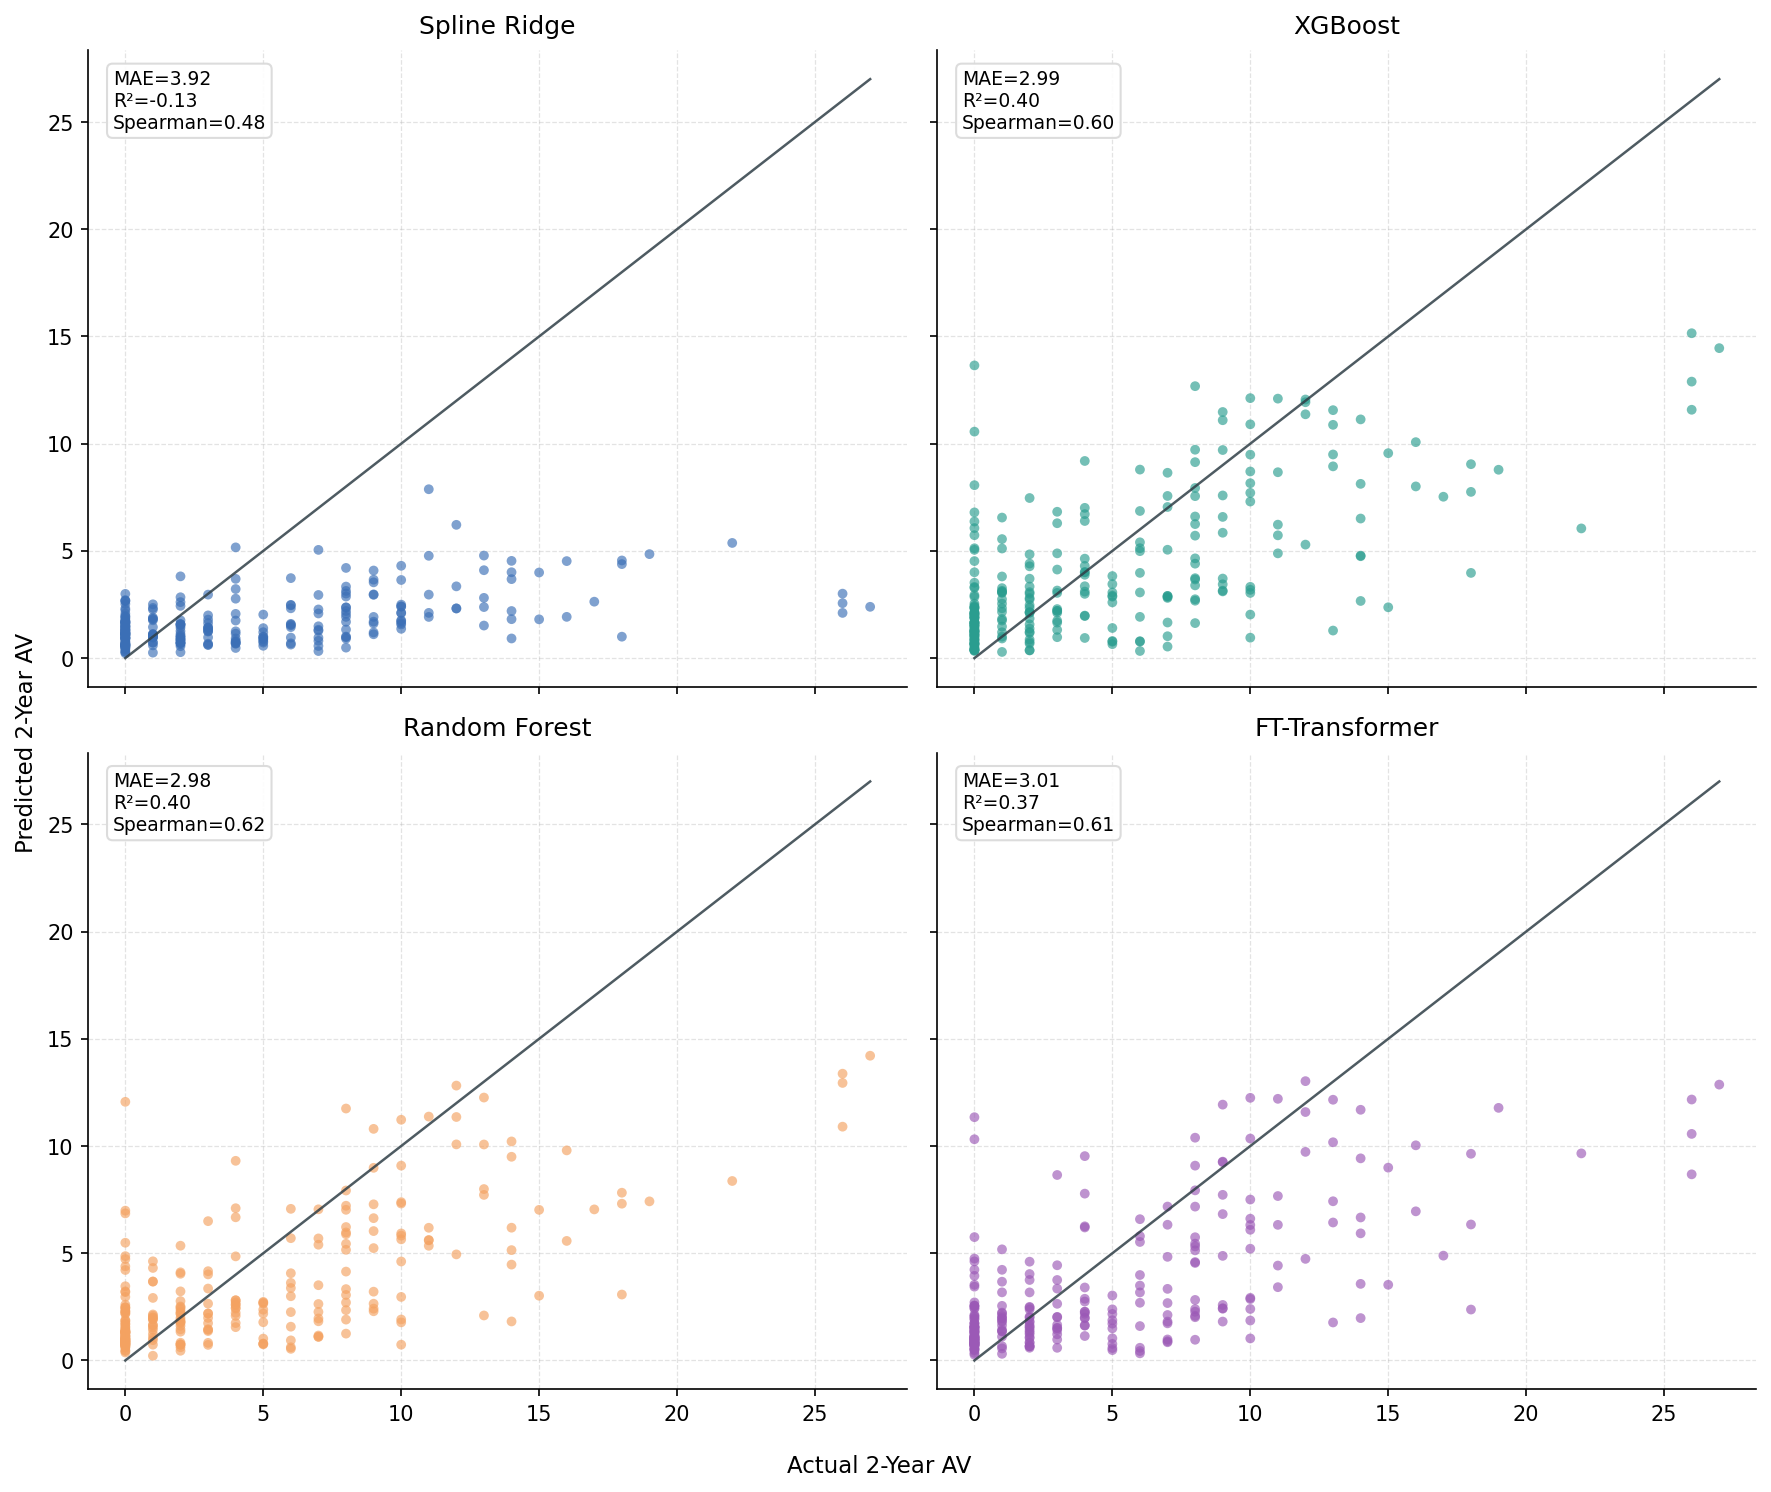

In [11]:
PLOT_MODELS = ['spline', 'xgb', 'rf', 'ftt']

y_true = preds_2024['av_2yr'].to_numpy(dtype=float)
lo, hi = float(y_true.min()), float(y_true.max())

fig, axes = plt.subplots(2, 2, figsize=(12, 10), dpi=150, sharex=True, sharey=True)
axes = axes.flatten()

for ax, model in zip(axes, PLOT_MODELS):
    col = f'pred_{model}'
    if col not in preds_2024.columns:
        ax.set_visible(False)
        continue
    y_pred = preds_2024[col].to_numpy(dtype=float)
    mae = float(np.mean(np.abs(y_true - y_pred)))
    sp  = float(spearmanr(y_true, y_pred).correlation)
    r2  = float(r2_score(y_true, y_pred))
    stats_text = chr(10).join([f'MAE={mae:.2f}', f'R²={r2:.2f}', f'Spearman={sp:.2f}'])

    ax.scatter(y_true, y_pred, s=22, alpha=0.65, edgecolor='none', color=MODEL_COLORS[model])
    ax.plot([lo, hi], [lo, hi], color='#2F3E46', linewidth=1.2, alpha=0.85)
    ax.set_title(MODEL_LABELS[model], fontsize=12, pad=8)
    ax.text(
        0.03, 0.97, stats_text,
        transform=ax.transAxes, va='top', ha='left', fontsize=9,
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.9, edgecolor='0.85'),
    )
    nice_axes(ax)

fig.supxlabel('Actual 2-Year AV', fontsize=11)
fig.supylabel('Predicted 2-Year AV', fontsize=11)
# fig.suptitle('2024 Draft Class — Predicted vs Actual 2-Year AV', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'nb_pred_vs_actual_2024.png'), dpi=150, bbox_inches='tight')
plt.show()